# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abdelrahmanmohamed05/FlyRank-AI/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, json, getpass, warnings, datetime
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ---- Hugging Face auth (Colab secret HF_TOKEN) ----
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    HF_TOKEN = getpass.getpass("Enter your Hugging Face READ token: ")

con = duckdb.connect()
con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
);
""")

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT_DIR = f"{REL}/fact_content_daily_performance"

# ---- output folders: work/outputs (data, NOT committed) and work/figures (committed) ----
def find_root():
    p = Path.cwd().resolve()
    for q in [p, *p.parents]:
        if (q / "work").is_dir():
            return q
    return p
ROOT = find_root()
OUT = ROOT / "work" / "outputs"
FIG = ROOT / "work" / "figures"
OUT.mkdir(parents=True, exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)
print("Exports will go to:", OUT, "and", FIG)

Exports will go to: /content/work/outputs and /content/work/figures


In [2]:
REQUIRED = {"client_hash_id", "content_hash_id", "report_date",
            "gsc_impressions", "gsc_clicks", "gsc_sum_position"}
_SRC_CACHE = {}

def _lit(files):
    return "[" + ", ".join(f"'{f}'" for f in files) + "]"

def get_source(start, end):
    """Read only the month=YYYY-MM partitions we need; fall back to the full glob."""
    key = (start, end)
    if key in _SRC_CACHE:
        return _SRC_CACHE[key]
    months = pd.period_range(pd.Timestamp(start), pd.Timestamp(end), freq="M")
    targeted = _lit([f"{FACT_DIR}/month={m}/*.parquet" for m in months])
    fallback = _lit([f"{FACT_DIR}/**/*.parquet"])
    last = None
    for cand in (targeted, fallback):
        try:
            con.execute(f"DESCRIBE SELECT * FROM read_parquet({cand})")
            _SRC_CACHE[key] = cand
            return cand
        except Exception as e:
            last = e
    raise RuntimeError(f"Could not read the fact table (check gated-dataset access). Last error: {last}")

cols = set(con.execute(f"DESCRIBE SELECT * FROM read_parquet({get_source('2026-02-01','2026-02-28')})").df()["column_name"])
assert not (REQUIRED - cols), f"Missing columns: {REQUIRED - cols}"
HAS_AVAIL = "gsc_data_available" in cols

def build_window(f_start, f_end, l_start, l_end):
    assert pd.Timestamp(f_end) <= pd.Timestamp(l_start), "feature window must end before the outcome window"
    mid = (pd.Timestamp(f_start) + pd.Timedelta(days=14)).date()
    avail = "AND gsc_data_available IS TRUE" if HAS_AVAIL else ""
    fw = f"report_date >= DATE '{f_start}' AND report_date < DATE '{f_end}'"
    lw = f"report_date >= DATE '{l_start}' AND report_date < DATE '{l_end}'"
    q = f"""
    SELECT * FROM (
        SELECT client_hash_id, content_hash_id,
            SUM(gsc_impressions) FILTER (WHERE {fw}) AS imp_f,
            SUM(gsc_clicks) FILTER (WHERE {fw}) AS clk_f,
            SUM(gsc_sum_position) FILTER (WHERE {fw}) AS sumpos_f,
            COUNT(DISTINCT report_date) FILTER (WHERE {fw} AND gsc_impressions > 0) AS days_active_f,
            SUM(gsc_clicks) FILTER (WHERE report_date >= DATE '{f_start}' AND report_date < DATE '{mid}') AS clk_early_f,
            SUM(gsc_clicks) FILTER (WHERE report_date >= DATE '{mid}' AND report_date < DATE '{f_end}') AS clk_late_f,
            SUM(gsc_impressions) FILTER (WHERE {lw}) AS imp_l,
            SUM(gsc_clicks) FILTER (WHERE {lw}) AS clk_l
        FROM read_parquet({get_source(f_start, l_end)})
        WHERE report_date >= DATE '{f_start}' AND report_date < DATE '{l_end}' {avail}
        GROUP BY client_hash_id, content_hash_id
    )
    WHERE imp_f >= 100 AND clk_f >= 3 AND imp_l >= 100
    """
    return con.execute(q).df()

FEATURES = ["log_imp_f", "log_clk_f", "ctr_f", "pos_f", "days_active_f", "trend_f"]

def make_frame(f_start, f_end, l_start, l_end):
    df = build_window(f_start, f_end, l_start, l_end)
    f_days = (pd.Timestamp(f_end) - pd.Timestamp(f_start)).days
    l_days = (pd.Timestamp(l_end) - pd.Timestamp(l_start)).days
    for c in ["clk_early_f", "clk_late_f"]:
        df[c] = df[c].fillna(0)
    df["ctr_f"] = df["clk_f"] / df["imp_f"]
    df["pos_f"] = df["sumpos_f"] / df["imp_f"]
    df["log_imp_f"] = np.log1p(df["imp_f"]); df["log_clk_f"] = np.log1p(df["clk_f"])
    df["trend_f"] = np.log((df["clk_late_f"] + 1) / (df["clk_early_f"] + 1))
    df["y"] = ((df["clk_l"] / l_days) < 0.7 * (df["clk_f"] / f_days)).astype(int)
    return df.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES + ["y"]).reset_index(drop=True)

CUR  = ("2026-02-01", "2026-03-01", "2026-03-01", "2026-04-01")
PREV = ("2026-01-01", "2026-02-01", "2026-02-01", "2026-03-01")
MAX_ROWS = 300_000

df = make_frame(*CUR)
if len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
print("Pages in scope:", len(df), "| decline rate:", round(df["y"].mean(), 3), "| clients:", df["client_hash_id"].nunique())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pages in scope: 29274 | decline rate: 0.338 | clients: 30


In [3]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score

def make_model():
    return HistGradientBoostingClassifier(max_depth=4, learning_rate=0.1, max_iter=150, random_state=42)

X, y, groups = df[FEATURES], df["y"], df["client_hash_id"]

# Out-of-fold scores: each page is scored by a model that never saw its client.
oof = np.zeros(len(df)); fold_auc = []
for tr, te in GroupKFold(5).split(X, y, groups):
    m = make_model().fit(X.iloc[tr], y.iloc[tr])
    oof[te] = m.predict_proba(X.iloc[te])[:, 1]
    fold_auc.append(roc_auc_score(y.iloc[te], oof[te]))
df["risk"] = oof   # a ranking score, NOT a calibrated probability

auc_grouped = float(np.mean(fold_auc)); ap_grouped = float(average_precision_score(y, oof))
top10 = df["risk"] >= df["risk"].quantile(0.90)
lift_top10 = float(df.loc[top10, "y"].mean() / df["y"].mean())
print(f"Grouped-CV AUC {auc_grouped:.3f} | avg precision {ap_grouped:.3f} | "
      f"top-decile decline rate {df.loc[top10,'y'].mean():.3f} vs base {df['y'].mean():.3f} (lift {lift_top10:.2f}x)")

Grouped-CV AUC 0.645 | avg precision 0.477 | top-decile decline rate 0.582 vs base 0.338 (lift 1.72x)


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [4]:
# ------------ ASSUMPTIONS (placeholders — change them, the queue re-ranks) ------------
ASSUMP = {
    "refresh_recovery_share": 0.30,   # share of at-risk clicks a refresh is assumed to protect
    "snippet_gap_closed":     0.50,   # share of the CTR gap to tier peers a title/meta rewrite is assumed to close
    "near_page1_click_lift":  0.20,   # assumed click lift from strengthening a page that sits at positions 11-20
    "effort_hours": {"Refresh content now": 3.0, "Rewrite title/meta": 0.5, "Strengthen content + internal links": 4.0},
}
THRESH = {"neg_trend": -0.15, "low_ctr_gap": 0.7, "low_data_days": 14, "low_data_clicks": 10}

# ------------ tiers, peer CTR, quantiles (feature month only) ------------
df["tier"] = pd.cut(df["pos_f"], [0, 3, 10, 20, 1e9], labels=["Top 3", "4-10", "11-20", "Deep"])
df["tier_ctr_median"] = df.groupby("tier", observed=True)["ctr_f"].transform("median")
df["ctr_gap"] = df["ctr_f"] / df["tier_ctr_median"]
q50_r, q75_r = df["risk"].quantile(0.50), df["risk"].quantile(0.75)
q75_imp = df["imp_f"].quantile(0.75); q50_imp = df["imp_f"].median()

page1 = df["pos_f"] <= 10
near1 = (df["pos_f"] > 10) & (df["pos_f"] <= 20)

# ------------ archetypes (first match wins) ------------
conds = [
    page1 & ((df["risk"] >= q75_r) | (df["trend_f"] <= THRESH["neg_trend"])),
    page1 & (df["ctr_gap"] < THRESH["low_ctr_gap"]),
    near1 & (df["imp_f"] >= q50_imp),
    df["pos_f"] > 20,
    page1 & (df["risk"] < q50_r) & (df["trend_f"] >= 0),
]
arch = ["Decaying page-one page", "Snippet underperformer", "Near page-one opportunity",
        "Deep long-tail page", "Stable page-one winner"]
act  = ["Refresh content now", "Rewrite title/meta", "Strengthen content + internal links",
        "No action (leave / consider consolidating)", "Protect and monitor"]
df["archetype"] = np.select(conds, arch, default="Steady middle")
df["action"] = np.select(conds, act, default="Monitor")

# ------------ reason codes (all that fired) ------------
RC_TEXT = {
    "RC1_HIGH_RISK":    "model risk score in the top quarter",
    "RC2_FALLING":      "clicks fell within the feature month (late vs early)",
    "RC3_LOW_CTR_TIER": "CTR well below peers at the same position tier",
    "RC4_HIGH_IMPR":    "high visibility (impressions in the top quarter)",
    "RC5_NEAR_PAGE1":   "sits at positions 11-20",
    "RC6_PAGE1":        "sits on page one (position 10 or better)",
    "RC7_LOW_DATA":     "thin data: few active days or few clicks",
}
flags = pd.DataFrame({
    "RC1_HIGH_RISK":    df["risk"] >= q75_r,
    "RC2_FALLING":      df["trend_f"] <= THRESH["neg_trend"],
    "RC3_LOW_CTR_TIER": df["ctr_gap"] < THRESH["low_ctr_gap"],
    "RC4_HIGH_IMPR":    df["imp_f"] >= q75_imp,
    "RC5_NEAR_PAGE1":   near1,
    "RC6_PAGE1":        page1,
    "RC7_LOW_DATA":     (df["days_active_f"] < THRESH["low_data_days"]) | (df["clk_f"] < THRESH["low_data_clicks"]),
})
names = np.array(list(RC_TEXT)); M = flags.values
df["reason_codes"] = [";".join(names[row]) for row in M]

# ------------ value (est. clicks per month at stake), effort, priority ------------
val_refresh = df["risk"] * df["clk_f"] * ASSUMP["refresh_recovery_share"]
val_snip    = np.maximum(0, df["tier_ctr_median"] - df["ctr_f"]) * df["imp_f"] * ASSUMP["snippet_gap_closed"]
val_near    = df["clk_f"] * ASSUMP["near_page1_click_lift"]
df["value_clicks_est"] = np.select(
    [df["action"] == "Refresh content now", df["action"] == "Rewrite title/meta",
     df["action"] == "Strengthen content + internal links"],
    [val_refresh, val_snip, val_near], default=0.0)
df["effort_hours"] = df["action"].map(ASSUMP["effort_hours"]).fillna(0.0)
df["priority_score"] = np.where(df["effort_hours"] > 0, df["value_clicks_est"] / df["effort_hours"].replace(0, np.nan), 0.0)

# ------------ review level (used in section 3) ------------
big = df["value_clicks_est"] >= df["value_clicks_est"].quantile(0.95)
df["review_level"] = np.select([flags["RC7_LOW_DATA"], big], ["verify data first", "senior review"], default="standard review")

queue = (df[df["effort_hours"] > 0].sort_values("priority_score", ascending=False).reset_index(drop=True))
queue.insert(0, "queue_rank", np.arange(1, len(queue) + 1))
queue["reason_text"] = [" | ".join(RC_TEXT[c] for c in codes.split(";") if c) for codes in queue["reason_codes"]]
print("Actionable pages in queue:", len(queue), "of", len(df))

Actionable pages in queue: 16008 of 29274


In [5]:
# ---- archetype -> action mapping table (what the playbook says) ----
mapping = (df.groupby(["archetype", "action"], observed=True)
             .agg(pages=("y", "size"), mean_risk=("risk", "mean"), decline_rate_mar=("y", "mean"),
                  median_est_value=("value_clicks_est", "median"))
             .reset_index().sort_values("pages", ascending=False))
display(mapping.round(3))

# ---- top of the queue: no IDs, only what a reviewer needs ----
show = ["queue_rank", "action", "archetype", "pos_f", "ctr_f", "imp_f", "risk", "value_clicks_est", "effort_hours", "priority_score", "review_level", "reason_text"]
display(queue[show].head(12).round(3))

,archetype,action,pages,mean_risk,decline_rate_mar,median_est_value
0,Decaying page-one page,Refresh content now,10016,0.448,0.442,0.780
4,Stable page-one winner,Protect and monitor,5691,0.221,0.226,0.000
5,Steady middle,Monitor,5406,0.385,0.314,0.000
3,Snippet underperformer,Rewrite title/meta,4233,0.303,0.307,5.011
1,Deep long-tail page,No action (leave / consider consolidating),2169,0.295,0.320,0.000
2,Near page-one opportunity,Strengthen content + internal links,1759,0.277,0.277,3.000


,queue_rank,action,archetype,pos_f,ctr_f,imp_f,risk,value_clicks_est,effort_hours,priority_score,review_level,reason_text
0,1,Rewrite title/meta,Snippet underperformer,0.040,0.000,92128.0,0.375,174.288,0.5,348.576,verify data first,CTR well below peers at the same position tier...
1,2,Rewrite title/meta,Snippet underperformer,5.475,0.001,116407.0,0.301,169.690,0.5,339.380,senior review,CTR well below peers at the same position tier...
2,3,Rewrite title/meta,Snippet underperformer,3.800,0.002,160699.0,0.268,167.470,0.5,334.941,senior review,CTR well below peers at the same position tier...
3,4,Rewrite title/meta,Snippet underperformer,0.519,0.000,90223.0,0.390,166.143,0.5,332.285,senior review,CTR well below peers at the same position tier...
4,5,Rewrite title/meta,Snippet underperformer,3.898,0.002,148256.0,0.223,160.934,0.5,321.868,senior review,CTR well below peers at the same position tier...
5,6,Rewrite title/meta,Snippet underperformer,6.709,0.000,81768.0,0.245,137.668,0.5,275.337,senior review,CTR well below peers at the same position tier...
6,7,Rewrite title/meta,Snippet underperformer,1.371,0.001,83657.0,0.159,134.078,0.5,268.157,senior review,CTR well below peers at the same position tier...
7,8,Rewrite title/meta,Snippet underperformer,7.514,0.001,72478.0,0.270,117.596,0.5,235.192,senior review,CTR well below peers at the same position tier...
8,9,Rewrite title/meta,Snippet underperformer,7.991,0.000,66357.0,0.290,114.518,0.5,229.035,senior review,CTR well below peers at the same position tier...
9,10,Rewrite title/meta,Snippet underperformer,6.750,0.002,79649.0,0.281,89.660,0.5,179.320,senior review,CTR well below peers at the same position tier...


trend_bin,falling,flat,rising
tier,,,
Top 3,0.404,0.336,0.302
4-10,0.425,0.264,0.315
11-20,0.426,0.332,0.301
Deep,0.400,0.363,0.271


trend_bin,falling,flat,rising
tier,,,
Top 3,1701,825,3065
4-10,5396,3412,8674
11-20,1229,545,2258
Deep,628,284,1257


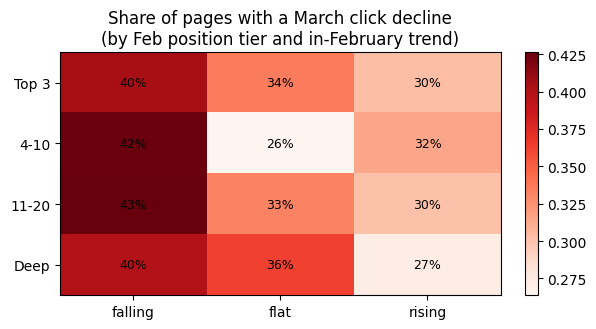

Observed: pages already falling inside February declined in March 41.9% of the time vs 30.2% for others (1.39x). Directional; part of this is ordinary regression to the mean.


In [6]:
# ---- decay / refresh insight: which combination of tier and in-month trend loses clicks next month? ----
df["trend_bin"] = pd.cut(df["trend_f"], [-np.inf, THRESH["neg_trend"], 0.15, np.inf], labels=["falling", "flat", "rising"])
decay = df.pivot_table(index="tier", columns="trend_bin", values="y", aggfunc="mean", observed=True)
counts = df.pivot_table(index="tier", columns="trend_bin", values="y", aggfunc="size", observed=True)
display(decay.round(3)); display(counts)

fig, ax = plt.subplots(figsize=(6, 3.4))
im = ax.imshow(decay.values.astype(float), cmap="Reds", aspect="auto")
ax.set_xticks(range(decay.shape[1])); ax.set_xticklabels(decay.columns)
ax.set_yticks(range(decay.shape[0])); ax.set_yticklabels(decay.index)
for i in range(decay.shape[0]):
    for j in range(decay.shape[1]):
        v = decay.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=9)
ax.set_title("Share of pages with a March click decline\n(by Feb position tier and in-February trend)")
plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout()
plt.savefig(FIG / "w07_decay_by_tier_trend.png", dpi=150); plt.show()

falling = df.loc[df.trend_bin == "falling", "y"].mean(); rest = df.loc[df.trend_bin != "falling", "y"].mean()
print(f"Observed: pages already falling inside February declined in March {falling:.1%} of the time vs {rest:.1%} for others "
      f"({falling / rest:.2f}x). Directional; part of this is ordinary regression to the mean.")

,pages,est_clicks,hours,clicks_per_hour
action,,,,
Strengthen content + internal links,1759,8797.2,7036.0,1.3
Refresh content now,10016,18111.1,30048.0,0.6
Rewrite title/meta,4233,36343.2,2116.5,17.2


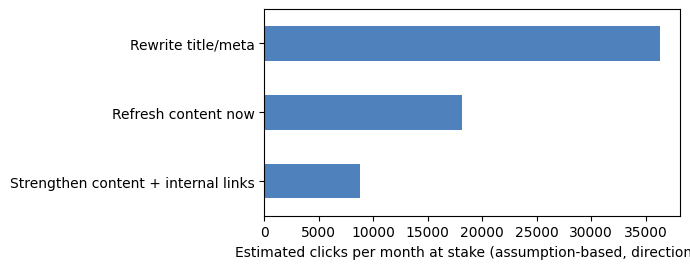

In [7]:
# ---- value by action (figure reused in the paper) ----
by_action = queue.groupby("action").agg(pages=("queue_rank", "size"), est_clicks=("value_clicks_est", "sum"),
                                       hours=("effort_hours", "sum")).sort_values("est_clicks")
by_action["clicks_per_hour"] = by_action["est_clicks"] / by_action["hours"]
display(by_action.round(1))
ax = by_action["est_clicks"].plot.barh(figsize=(7, 2.8), color="#4f81bd")
ax.set_xlabel("Estimated clicks per month at stake (assumption-based, directional)"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(FIG / "w07_value_by_action.png", dpi=150); plt.show()

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use (decision-support only)**

- **Who:** a content strategist or SEO analyst who owns a client's content calendar.
- **What for:** to decide *which pages to look at first* this month, using a ranked queue with plain-language reason codes.
- **Not for:** publishing, rewriting, or removing anything automatically; judging an individual writer; promising any traffic outcome to a client.

**Cost / value thinking**

- Value is *estimated clicks per month at stake*; cost is *analyst hours*. Priority = value ÷ hours, so a 30-minute title rewrite on a big page can outrank a 4-hour content rebuild.
- Uplift shares and hours are **placeholders** (see `ASSUMP`). The ranking is directional; the team should replace the placeholders with its own numbers and re-run.

**Where it stops being valid (limits)**

- One frozen snapshot, one month-to-month transition (Feb → Mar 2026). Seasonality, algorithm updates, and site changes are not modeled.
- Only pages with enough visibility (≥100 impressions and ≥3 clicks in February, ≥100 impressions in March). Pages that vanished are not in the data, so decline is probably *under*-counted (survivorship).
- The score is a **ranking score, not a calibrated probability**. It is *observed correlation*, not proof that a refresh causes recovery.
- The warehouse is an unbalanced panel: clients have different history depth, so results may not carry to new clients.
- Part of the "decay" signal is regression to the mean: unusually good months tend to look worse next month.

In [8]:
print(f"Scope check -> pages: {len(df):,} | clients: {df.client_hash_id.nunique():,} | windows: {CUR[0]}..{CUR[1]} -> {CUR[2]}..{CUR[3]}")
print(f"Measured (client-grouped) AUC {auc_grouped:.2f}; top-decile lift {lift_top10:.2f}x. Directional, exploratory.")

# ---- cost / value snapshot: what does a realistic review budget buy? ----
budget_rows = []
for hours_budget in (10, 20, 40):
    q = queue.copy(); q["cum_hours"] = q["effort_hours"].cumsum()
    sel = q[q["cum_hours"] <= hours_budget]
    budget_rows.append((hours_budget, len(sel), sel["value_clicks_est"].sum()))
budget = pd.DataFrame(budget_rows, columns=["analyst_hours", "pages_actioned", "est_clicks_at_stake"])
budget["est_clicks_per_hour"] = budget["est_clicks_at_stake"] / budget["analyst_hours"]
display(budget.round(1))
print("Reading: estimates depend on the placeholder assumptions above; treat as ordering, not forecasts.")

Scope check -> pages: 29,274 | clients: 30 | windows: 2026-02-01..2026-03-01 -> 2026-03-01..2026-04-01
Measured (client-grouped) AUC 0.65; top-decile lift 1.72x. Directional, exploratory.


,analyst_hours,pages_actioned,est_clicks_at_stake,est_clicks_per_hour
0,10,20,2171.4,217.1
1,20,40,3367.0,168.3
2,40,80,5204.0,130.1


Reading: estimates depend on the placeholder assumptions above; treat as ordering, not forecasts.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**A person must check, for every page in the queue**

1. **Is the data real?** Rows flagged `verify data first` (thin data) are checked in Search Console before any work.
2. **Is there a known reason for the drop?** Seasonality, a deleted or redirected page, a site migration, a tracking change, a SERP-feature change.
3. **Does the action fit the page's job?** A page can rank well but exist for a reason other than clicks (legal, support, brand).
4. **Is the estimate believable?** Rows flagged `senior review` (top 5% by estimated value) get a second pair of eyes because one wrong call costs the most.
5. **Record the outcome** (did the action help after 4–8 weeks?) so the playbook can be checked against reality.

**No-go list — never automate**

- Publishing, rewriting, deleting, redirecting, or de-indexing pages straight from the queue.
- Any client-facing promise such as "this refresh will recover X clicks".
- Acting on pages with `RC7_LOW_DATA` without checking the raw data.
- Using the score to rank or evaluate people (writers, teams, clients).
- Applying the queue to a brand-new client, a new market, or a new time window without re-running the validation from Week 6.
- Exposing client names, URLs, or queries in any report or paper figure.

In [9]:
print("Review levels in the queue:")
display(queue["review_level"].value_counts().rename("pages").to_frame())

nogo = pd.DataFrame({"no_go": [
    "Auto-publish / auto-rewrite / auto-delete / auto-redirect",
    "Client promises about recovered clicks",
    "Acting on thin-data pages without raw-data check",
    "Ranking or evaluating people with the score",
    "Using on new clients / new windows without re-validation",
    "Showing client names, URLs or queries"]})
display(nogo)

Review levels in the queue:


,pages
review_level,
verify data first,10266
standard review,4560
senior review,1182


,no_go
0,Auto-publish / auto-rewrite / auto-delete / au...
1,Client promises about recovered clicks
2,Acting on thin-data pages without raw-data check
3,Ranking or evaluating people with the score
4,Using on new clients / new windows without re-...
5,"Showing client names, URLs or queries"


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Light, monthly, and human-read. A trigger does **not** auto-retrain; it tells a person to look.

| Trigger | Threshold (starting point) | Why it matters |
|---|---|---|
| Feature drift (PSI) | any feature PSI > 0.25 | inputs no longer look like what the model saw |
| Ranking quality | grouped AUC drops > 0.05 vs baseline | scores order pages worse |
| Top-decile lift | < 1.2× for the top-10% risk pages | the queue no longer beats a random pick |
| Base rate shift | decline rate moves > 5 points | the world changed (season, update) |
| Data volume | pages in scope fall > 30% | tracking or ingestion problem |
| Calendar | retrain and re-validate at least quarterly | slow drift |

In [10]:
TRIGGERS = {"psi_max": 0.25, "auc_drop": 0.05, "lift_min": 1.2, "prevalence_shift": 0.05, "volume_drop": 0.30}

def psi(ref, cur, bins=10):
    edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0
    edges[0], edges[-1] = -np.inf, np.inf
    r = np.histogram(ref, edges)[0] / len(ref); c = np.histogram(cur, edges)[0] / len(cur)
    r, c = np.clip(r, 1e-4, None), np.clip(c, 1e-4, None)
    return float(np.sum((c - r) * np.log(c / r)))

def check_triggers(ref_df, cur_df, base_auc, cur_auc, cur_lift):
    fired = []
    psis = {f: psi(ref_df[f].values, cur_df[f].values) for f in FEATURES}
    for f, v in psis.items():
        if v > TRIGGERS["psi_max"]: fired.append(f"feature drift: {f} PSI={v:.2f}")
    if not np.isnan(cur_auc) and base_auc - cur_auc > TRIGGERS["auc_drop"]:
        fired.append(f"ranking quality: AUC {cur_auc:.2f} vs baseline {base_auc:.2f}")
    if cur_lift < TRIGGERS["lift_min"]: fired.append(f"top-decile lift {cur_lift:.2f}x below {TRIGGERS['lift_min']}x")
    if abs(cur_df["y"].mean() - ref_df["y"].mean()) > TRIGGERS["prevalence_shift"]:
        fired.append(f"base rate moved {ref_df['y'].mean():.3f} -> {cur_df['y'].mean():.3f}")
    if len(cur_df) < (1 - TRIGGERS["volume_drop"]) * len(ref_df): fired.append("data volume fell more than 30%")
    return psis, fired

# Demonstration: treat Jan->Feb as the reference and Feb->Mar as the "new month"
try:
    prev = make_frame(*PREV)
    if len(prev) > MAX_ROWS: prev = prev.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
    m_prev = make_model().fit(prev[FEATURES], prev["y"])
    p_cur = m_prev.predict_proba(df[FEATURES])[:, 1]
    auc_time = float(roc_auc_score(df["y"], p_cur))
    lift_time = float(df.loc[p_cur >= np.quantile(p_cur, 0.9), "y"].mean() / df["y"].mean())
    psis, fired = check_triggers(prev, df, auc_grouped, auc_time, lift_time)
    display(pd.Series(psis, name="PSI (Jan->Feb vs Feb->Mar)").round(3).to_frame())
    print(f"Time-aware AUC (train Jan->Feb, test Feb->Mar): {auc_time:.3f}")
    print("Triggers fired in this demo:", fired if fired else "none")
except Exception as e:
    prev, auc_time, lift_time, psis, fired = None, float("nan"), float("nan"), {}, []
    print("Monitoring demo skipped:", e)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,PSI (Jan->Feb vs Feb->Mar)
log_imp_f,0.027
log_clk_f,0.014
ctr_f,0.022
pos_f,0.071
days_active_f,0.000
trend_f,0.105


Time-aware AUC (train Jan->Feb, test Feb->Mar): 0.633
Triggers fired in this demo: ['base rate moved 0.249 -> 0.338']


## 5. Exports for the paper

*Write the queue (and figures) to `work/outputs/` and `work/figures/` — the paper builds on these files.*

- `work/outputs/action_queue.csv` — the ranked queue. **Stays out of git by design** (CI leak-guard); this notebook regenerates it.
- `work/outputs/playbook_metrics.json` — the receipts for every number in the paper. **Commit this.**
- `work/figures/w07_*.png` — figures to reuse. **Commit these.**

In [11]:
export_cols = ["queue_rank", "client_hash_id", "content_hash_id", "archetype", "action", "reason_codes",
               "risk", "value_clicks_est", "effort_hours", "priority_score", "review_level",
               "tier", "pos_f", "ctr_f", "imp_f", "clk_f", "trend_f"]
export = queue[export_cols].rename(columns={"risk": "risk_score"})

# guard: only pseudonymous hashes and numeric features; no free-text identifiers
assert all(c in export.columns for c in ["queue_rank", "action", "reason_codes"])
assert not any(c in export.columns for c in ["url", "query", "domain", "client_name"])
export.to_csv(OUT / "action_queue.csv", index=False)

metrics = {
    "generated_on": str(datetime.date.today()),
    "windows": {"feature": [CUR[0], CUR[1]], "outcome": [CUR[2], CUR[3]]},
    "label": "daily clicks in outcome month < 70% of daily clicks in feature month",
    "n_pages": int(len(df)), "n_clients": int(df["client_hash_id"].nunique()),
    "decline_rate": float(df["y"].mean()),
    "auc_client_grouped_5fold": auc_grouped, "avg_precision_grouped": ap_grouped,
    "auc_time_aware_jan_to_feb_train": None if np.isnan(auc_time) else auc_time,
    "top_decile_lift": lift_top10,
    "queue_size": int(len(queue)),
    "queue_by_action": {k: int(v) for k, v in queue["action"].value_counts().items()},
    "review_levels": {k: int(v) for k, v in queue["review_level"].value_counts().items()},
    "falling_vs_other_decline_ratio": float(falling / rest),
    "assumptions": ASSUMP, "thresholds": THRESH, "monitoring_triggers": TRIGGERS,
    "notes": "Scores are ranking scores, not calibrated probabilities. Values are assumption-based and directional.",
}
with open(OUT / "playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Wrote:")
for p in [OUT / "action_queue.csv", OUT / "playbook_metrics.json", FIG / "w07_decay_by_tier_trend.png", FIG / "w07_value_by_action.png"]:
    print(" -", p.relative_to(ROOT) if ROOT in p.parents else p, f"({p.stat().st_size:,} bytes)")
print("\nReminder: commit metrics JSON + figures; do NOT commit action_queue.csv (CI leak-guard).")

Wrote:
 - work/outputs/action_queue.csv (4,682,025 bytes)
 - work/outputs/playbook_metrics.json (1,522 bytes)
 - work/figures/w07_decay_by_tier_trend.png (53,421 bytes)
 - work/figures/w07_value_by_action.png (29,756 bytes)

Reminder: commit metrics JSON + figures; do NOT commit action_queue.csv (CI leak-guard).


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.